In [1]:
# %pip install yt-dlp requests openai-whisper moviepy
import subprocess
subprocess.run(['pip', 'install', 'yt-dlp', 'requests', 'openai-whisper', 'moviepy'], check=True)
print("Dependencies installed")

Dependencies installed


In [2]:
inputs = [
  {
    "channel_name": "Vsauce",
    "channel_url": "https://www.youtube.com/@Vsauce",
    "videos": [
      {
        "title": "The Brachistochrone",
        "url": "https://www.youtube.com/watch?v=skvnj67YGmw"
      }
    ]
  },
  {
    "channel_name": "Veritasium",
    "channel_url": "https://www.youtube.com/@veritasium",
    "videos": [
      {
        "title": "The Biggest Misconception in Physics",
        "url": "https://www.youtube.com/watch?v=lcjdwSY2AzM"
      },
      {
        "title": "Why Do Escalator Steps Have Teeth?",
        "url": "https://www.youtube.com/watch?v=tZ8ehplVFp4"
      },
      {
        "title": "The Most Controversial Problem in Philosophy",
        "url": "https://www.youtube.com/watch?v=XeSu9fBJ2sI"
      }
    ]
  },
  {
    "channel_name": "3Blue1Brown",
    "channel_url": "https://www.youtube.com/@3blue1brown",
    "videos": [
      {
        "title": "Why colliding blocks compute pi",
        "url": "https://www.youtube.com/watch?v=6dTyOl1fmDo"
      },
      {
        "title": "But what is quantum computing? (Grover's Algorithm)",
        "url": "https://www.youtube.com/watch?v=RQWpF2Gb-gU"
      },
      {
        "title": "Solving Wordle using information theory",
        "url": "https://www.youtube.com/watch?v=v68zYyaEmEA"
      },
    ]
  },
]

In [4]:
import json

# Step 1: User Configuration
current_input = inputs[2]
channel_name = current_input["channel_name"]
video_url = current_input["videos"][2]["url"]

# Load API key from config file
with open("config.json", "r") as config_file:
    config = json.load(config_file)
    gemini_api_key = config["gemini_api_key"]

debug_mode = False

# Other variables
import os
import json
import time
import requests
import re
import subprocess
import glob

# gemini_model = "gemini-2.5-flash-preview-09-2025"
gemini_model = "gemini-2.5-flash"
api_url = f"https://generativelanguage.googleapis.com/v1beta/models/{gemini_model}:generateContent?key={gemini_api_key}"

def extract_video_id(url):
    match = re.search(r'(?<=v=)[\w-]+', url)
    if match:
        return match.group(0)
    match = re.search(r'youtu\.be/([\w-]+)', url)
    if match:
        return match.group(1)
    return None

video_id = extract_video_id(video_url)
if not video_id:
    raise ValueError(f"Could not extract video ID from URL: {video_url}")

output_folder = f"out/{video_id}"
temp_folder = f"temp/{video_id}"
os.makedirs(output_folder, exist_ok=True)
os.makedirs(temp_folder, exist_ok=True)

print(f"Video ID: {video_id}")
print(f"Debug mode: {debug_mode}")
print(f"Output folder: {output_folder}")

Video ID: v68zYyaEmEA
Debug mode: False
Output folder: out/v68zYyaEmEA


In [5]:
# Step 3: Download YouTube Video

def download_video(url, output_path):
    try:
        cmd = [
            'yt-dlp',
            '--format', 'best[height<=720][ext=mp4]/best[ext=mp4]/best',
            '--output', os.path.join(output_path, '%(id)s.%(ext)s'),
            '--no-playlist',
            url
        ]

        subprocess.run(cmd, capture_output=True, text=True, check=True)

        downloaded_files = glob.glob(os.path.join(output_path, f"{video_id}.*"))
        downloaded_files = [
            p for p in downloaded_files
            if os.path.isfile(p)
            and os.path.getsize(p) > 0
            and not p.endswith((
                '.part',
                '.ytdl',
                '.tmp',
                '.info.json',
                '.description',
            ))
        ]
        if not downloaded_files:
            raise Exception("No downloaded file found")

        return sorted(downloaded_files)[0]
    except Exception as e:
        raise Exception(f"Download failed: {e}")


def find_existing_video_path(output_path):
    preferred_exts = ['.mp4', '.mkv', '.webm', '.mov']

    candidates = []
    for ext in preferred_exts:
        candidates.extend(glob.glob(os.path.join(output_path, f"{video_id}{ext}")))

    if not candidates:
        candidates = glob.glob(os.path.join(output_path, f"{video_id}.*"))

    candidates = [
        p for p in candidates
        if os.path.isfile(p)
        and os.path.getsize(p) > 0
        and not p.endswith((
            '.part',
            '.ytdl',
            '.tmp',
            '.info.json',
            '.description',
        ))
    ]

    if not candidates:
        return None

    def sort_key(p):
        lp = p.lower()
        # Prefer mp4, then other known video extensions, then everything else
        if lp.endswith('.mp4'):
            rank = 0
        elif any(lp.endswith(ext) for ext in preferred_exts):
            rank = 1
        else:
            rank = 2
        return (rank, lp)

    return sorted(set(candidates), key=sort_key)[0]


existing_video_path = find_existing_video_path(temp_folder)
if existing_video_path:
    video_path = existing_video_path
    print(f"🎞️ Video already present, skipping download: {video_path}")
else:
    video_path = download_video(video_url, temp_folder)
    print(f"Video downloaded: {video_path}")


🎞️ Video already present, skipping download: temp/v68zYyaEmEA/v68zYyaEmEA.mp4


In [6]:
# Step 4: Convert Video to Audio Chunks and Get Transcript
import whisper

# Check if transcript already exists
transcript_path = os.path.join(output_folder, f"{video_id}_transcript.json")

if os.path.exists(transcript_path):
    print(f"📄 Loading existing transcript: {transcript_path}")
    with open(transcript_path, 'r') as f:
        transcript_data = json.load(f)
    print(f"✅ Transcript loaded from file!")
    print(f"Language: {transcript_data['language']}")
    print(f"Total words: {len(transcript_data['words'])}")
else:
    print(f"🎵 Transcript not found, processing full audio...")
    
    def convert_video_to_audio(video_path):
        """Convert entire video to single audio file using ffmpeg"""
        base_name = os.path.splitext(os.path.basename(video_path))[0]
        audio_path = os.path.join(temp_folder, f"{base_name}_full_audio.wav")
        
        print(f"🔄 Converting video to audio: {audio_path}")
        cmd = [
            'ffmpeg', '-i', video_path,
            '-vn',  # No video
            '-acodec', 'pcm_s16le',  # PCM 16-bit little-endian
            '-ar', '16000',  # Sample rate 16kHz (optimal for Whisper)
            '-ac', '1',  # Mono channel
            '-y',  # Overwrite output file
            audio_path
        ]
        
        result = subprocess.run(cmd, capture_output=True, text=True, check=True)
        print(f"✅ Audio conversion completed: {audio_path}")
        return audio_path

    def get_word_level_transcript_full(audio_path):
        """Get word-level transcript with timestamps from full audio"""
        print(f"🧠 Loading Whisper model...")
        model = whisper.load_model("base")
        
        print(f"🎤 Transcribing audio with word timestamps...")
        result = model.transcribe(audio_path, word_timestamps=True)
        
        all_words = []
        word_index = 0

        for segment in result['segments']:
            for word_info in segment['words']:
                all_words.append({
                    'index': word_index,
                    'word': word_info['word'].strip(),
                    'start': word_info['start'],
                    'end': word_info['end']
                })
                word_index += 1
        
        return {
            'language': result['language'],
            'words': all_words
        }

    # Convert full video to audio and transcribe
    audio_path = convert_video_to_audio(video_path)
    transcript_data = get_word_level_transcript_full(audio_path)

    # Save transcript to JSON
    with open(transcript_path, 'w') as f:
        json.dump(transcript_data, f, indent=2)

    print(f"✅ Transcript saved: {transcript_path}")
    print(f"Language: {transcript_data['language']}")
    print(f"Total words: {len(transcript_data['words'])}")

📄 Loading existing transcript: out/v68zYyaEmEA/v68zYyaEmEA_transcript.json
✅ Transcript loaded from file!
Language: en
Total words: 6343


In [24]:
# Step 2.5: Setup System Prompt for Training (Run Once Only)

training_folder = "in/training_data"
with open(os.path.join(training_folder, "input.txt"), 'r') as f:
  training_data = f.read()
with open(os.path.join(training_folder, "output.json"), 'r') as f:
  expected_output = json.load(f)

with open(os.path.join(training_folder, "input2.txt"), 'r') as f:
  training_data2 = f.read()
with open(os.path.join(training_folder, "output2.json"), 'r') as f:
  expected_output2 = json.load(f)

system_prompt = f"""
You are an expert viral content curator who identifies compelling story segments from videos. You'll be given a transcript of a video and your task is to imagine the video from the given transacript (there can be multiple speakers at a time with overlapping words) and select the most engaging excerpts to create viral stories to be posted on social media. Each story should have a captivating title to be posted on social and a sequence of clips (1 or more) that flow together to tell a complete narrative.

TITLE CRAFTING RULES:
1. Use questions that create curiosity gaps
2. Include counterintuitive or surprising elements
3. Reference specific fascinating concepts
4. Create emotional hooks
5. Transcript may contain spelling errors, but ensure titles are grammatically correct
6. Keep under 80 characters for social media optimization

STORY SELECTION RULES:
1. Look for complete thought sequences that tell a story
2. Find moments where the speaker poses interesting questions or facts
3. Identify explanations of counterintuitive phenomena
4. Capture demonstrations or visual examples
5. Include surprising facts or revelations
6. [VERY IMPORTANT] Each story should be complete in itself - from start to end, each story will be posted as a standalone video comprising of the individual clips (1 or more) joined together. Each story's end and start shouldn't feel abrupt or starting off randomly, ensure proper context is included.
7. [VERY IMPORTANT] Transcript may contain spelling errors, the stories however should use EXACTLY the same words from transcript, don't correct the grammar, keep punctuation as it is. This is because later the words from your output will be used to search and extract the index out of the input transcript to create the clips. If you change the words/spelling/punctuation, we won't be able to find the words back in the transcript.
8. [VERY IMPORTANT] Each story can contain multiple clips i.e. multiple segments from the transcript. Since, you'll be breaking the transcript multiple times to extract the most concise excerpt from the transcript, ensure that each time a continous sequence of words is broken you start a new clip. Ensure that clips flow logically even when jumping across transcript. Any of the complete story (joined clips) should not feel like ending or starting abruptly or mid sentence.
9. Each clip of a story should be a continuous segment of the transcript. This is crucial: there is NO limit on the number of clips generated but only on the combined clips word limit. This means that you can break the transcript unlimited times to (and form new clips) to only select the most concise parts.
10. [VERY IMPORTANT] Combined individual stories can be 100-500 words long (Entire story duration should be around 30 to 120 seconds when spoken, this is because longer videos are not ideal to be posted on social media, shorts are likely to go viral more).
11. Each story should be independent of one another and can be posted separately on social media as standalone videos.
12. Read each standalone story as if it's the only content being posted, it should not contain any statement/question/reference that requires additional context from other stories. If absolutely necessary to maintain the narrative flow, you can include a very brief reference to another story, but it should be done in a way that only exact word clips from the transcript are used, no additional words should be added in the reference.
13. Don't include any stories which reference or require the context of other stories to make sense, each story should be complete in itself.
14. Skip any part of the transcript which is not engaging or doesn't add value to the story, even if it means skipping large chunks of the transcript. The goal is to create engaging stories, not to use the entire transcript. [VERY IMPORTANT] - Whenever you skip a segment in between, ensure you cut it into a new clip. Each clip should only contain continuous segments from the transcript.
15. You can cut lines in between to make them feel starting perfectly, for eg: consider the sentence "I mean, have you ever stopped to think what happens to the artists?" If this sentence is part of a story, you can start the clip from "Have you ever stopped to think what happens to the artists?" to make it feel more engaging and starting perfectly, even though the original transcript starts with "I mean, ..."
16. Make sure whenever you cut a statement, you start a new clip. One clip should only contain continuous words from the transcript, if you cut in between a statement, it should be treated as two separate clips.
17. VERY IMPORTANT: Enure that the context of one story doesn't spans to others. If a concept/fact/incident is too long to summarize in one story with given constraints, don't output the story at all. It's very crucial that all given stories are complete in themselves and independently complete. If no such stories are possible under given constraits, you can output empty JSON array.
For example: Consider if a story contains following statement: "There have been many variations of this problem.", the word "this" refers to a problem, now it may happen that the original problem is described elsewhere in the transcript and it's description is not be included in current story, in this case avoid using this statement and if it's not possible to omit it while keeping the story structure consistent and easy flowing, don't include the story at all!

======================================================================

TRAINING EXAMPLE 1 - Learn from following sample transcript, the output contains two stories, one with a single clip and another with multiple clips which are compatible to be stitched together as one story. Your output shuold similarly contain one to many clips per story. Notice how each individual story when stiched together creates a complete narrative arc with a clear beginning, middle and end, even when clips are taken from different parts of the transcript.

SAMPLE TRANSCRIPT: {training_data}

EXPECTED OUTPUT: {json.dumps(expected_output)}

======================================================================

TRAINING EXAMPLE 2 - Notice how it cuts the transcript mid sentence, mid word, rigorously extracting only the relevant parts. Carefully starting a new clip on every cut. Even then the entire story doesn't feels starting off arbitrarily/randomly or ending off abruptly. 

SAMPLE TRANSCRIPT: {training_data2}

EXPECTED OUTPUT: {json.dumps(expected_output2)}

======================================================================

Return ONLY JSON array with the structure shown above in EXPECTED OUTPUT.
"""

print(f"Approx system prompt token length: {len(system_prompt.split())} (words)")

Approx system prompt token length: 9648 (words)


In [8]:
length = len(transcript_data['words'])
transcript_data_joined = ' '.join([word['word'] for word in transcript_data['words'][0:length]])
transcript_data_joined

"The game Wordal has gone pretty viral in the last month or two, and never one to overlook an opportunity for a math lesson. It occurs to me that this game makes for a very good central example in a lesson about information theory, and in particular a topic known as entropy. You see, like a lot of people I got kind of sucked into the puzzle, and like a lot of programmers, I also got sucked into trying to write an algorithm that would play the game as optimally as it could. And what I thought I'd do here is just talk through with you some of my process in that, and explain some of the math that went into it, since the whole algorithm centers on this idea of entropy. First things first, in case you haven't heard of it, what is Wordal? And to kill two birds with one stone here while we go through the rules of the game, let me also preview where we're going with this, which is to develop a little algorithm that will basically play the game for us. So I haven't done today's Wordal, this is 

In [9]:
# Step 5: Process Transcript with Gemini for Stories

def process_with_gemini(transcript_data):
    current_prompt = f"""
Analyze this actual transcript and create viral-worthy story segments following the patterns you learned.

Transcript ({length} words):
{transcript_data}

Return ONLY the JSON array following the exact structure from training.
"""

    print(f"Approx system prompt token length: {len(system_prompt.split())} (words)")
    print(f"Approx current prompt token length: {len(current_prompt.split())} (words)")
    payload = {
        "contents": [{"parts": [{"text": system_prompt + current_prompt}]}],
        "generationConfig": {
            "responseMimeType": "application/json"
        },
    }

    try:
        response = requests.post(api_url, headers={'Content-Type': 'application/json'}, json=payload)
        response.raise_for_status()

        json_text = response.json().get('candidates', [{}])[0].get('content', {}).get('parts', [{}])[0].get('text', '[]')

        if json_text.strip().startswith('```json'):
            json_text = json_text.strip()[7:-3].strip()

        stories = json.loads(json_text)
        return stories

    except Exception as e:
        print(f"Error during Gemini processing: {e}")
        return None


# Idempotency: load existing stories if present
stories_path = os.path.join(output_folder, f"{video_id}_stories.json")

stories = None
if os.path.exists(stories_path):
    print(f"📄 Loading existing stories: {stories_path}")
    try:
        with open(stories_path, 'r') as f:
            stories = json.load(f)
        print(f"✅ Stories loaded from file!")
    except Exception as e:
        print(f"⚠️ Failed to load existing stories JSON ({e}). Re-generating...")

if stories is None:
    stories = process_with_gemini(transcript_data_joined)
    if stories is None:
        raise RuntimeError("Gemini returned no stories (see error above)")

    # Save stories to JSON
    with open(stories_path, 'w') as f:
        json.dump(stories, f, indent=2)

    print(f"✅ Stories saved: {stories_path}")


📄 Loading existing stories: out/v68zYyaEmEA/v68zYyaEmEA_stories.json
✅ Stories loaded from file!


In [10]:
# credits: https://chatgpt.com/share/69a88efe-dff4-8000-b691-1d0b55d2a05b

import re
from difflib import SequenceMatcher

# -------------------------
# Helper functions
# -------------------------

def normalize_word(w):
    return re.sub(r"[^\w]", "", w.lower())

def similarity(a, b):
    return SequenceMatcher(None, a, b).ratio()

def window_similarity(a_words, b_words):
    return similarity(" ".join(a_words), " ".join(b_words))


# -------------------------
# Preprocess transcript
# -------------------------

transcript_words_raw = [w['word'] for w in transcript_data['words']]
transcript_words = [normalize_word(w) for w in transcript_words_raw]

# processed_stories will store start and end index and timestamps for each clip generated
processed_stories = []

fuzzy_match_length = 8
SIM_THRESHOLD = 0.6


# -------------------------
# Story processing
# -------------------------

for story in stories:
    skip_story = False
    story_clips = []

    for clip_obj in story['clips']:

        clip_words_raw = clip_obj['clip'].split()
        clip_words = [normalize_word(w) for w in clip_words_raw]

        clip_length = len(clip_words)

        anchor = min(fuzzy_match_length, clip_length)

        start_anchor = clip_words[:anchor]
        end_anchor = clip_words[-anchor:]

        best_start = None
        best_start_score = 0

        best_end = None
        best_end_score = 0

        # -------------------------
        # Find best start
        # -------------------------

        for i in range(len(transcript_words) - anchor):
            window = transcript_words[i:i+anchor]

            score = window_similarity(start_anchor, window)

            if score > best_start_score:
                best_start_score = score
                best_start = i

        # -------------------------
        # Find best end
        # -------------------------

        for i in range(len(transcript_words) - anchor):
            window = transcript_words[i:i+anchor]

            score = window_similarity(end_anchor, window)

            if score > best_end_score:
                best_end_score = score
                best_end = i + anchor - 1

        # -------------------------
        # Validate
        # -------------------------

        if (
            best_start is None or
            best_end is None or
            best_start_score < SIM_THRESHOLD or
            best_end_score < SIM_THRESHOLD or
            best_end <= best_start
        ):
            print(f"⚠️ Could not fuzzily match clip in transcript: '{clip_obj['clip'][:80]}...'")
            skip_story = True
            break

        start_index = best_start
        end_index = best_end

        start_time = transcript_data['words'][start_index]['start']
        end_time = transcript_data['words'][end_index]['end']

        story_clips.append({
            'start_index': start_index,
            'end_index': end_index,
            'word_count': end_index - start_index + 1,
            'start_time': float(start_time),
            'end_time': float(end_time),
            'duration': float(end_time - start_time),
            'clip': ' '.join(
                transcript_words_raw[start_index:end_index+1]
            )
        })

    if not skip_story:
        processed_stories.append({
            'story_title': story['story_title'],
            'total_duration': sum([clip['duration'] for clip in story_clips]),
            'total_word_count': sum([clip['word_count'] for clip in story_clips]),
            'clips': story_clips,
        })

processed_stories

[{'story_title': 'How does this Wordle bot consistently get birdies?',
  'total_duration': 77.27999999999999,
  'total_word_count': 295,
  'clips': [{'start_index': 204,
    'end_index': 223,
    'word_count': 20,
    'start_time': 55.46,
    'end_time': 60.24,
    'duration': 4.780000000000001,
    'clip': "The goal of Wordal is to guess a mystery 5 letter word, and you're given 6 different chances to guess."},
   {'start_index': 224,
    'end_index': 315,
    'word_count': 92,
    'start_time': 60.8,
    'end_time': 84.48,
    'duration': 23.680000000000007,
    'clip': "For example, my wordal bot suggests that I start with the guess crane. Each time that you make a guess, you get some information about how close your guess is to the true answer. Here the gray box is telling me there's no C in the actual answer. The yellow box is telling me there isn't R, but it's not in that position. The green box is telling me that the secret word does have an A, and it's in the third position, an

In [11]:
for i, story in enumerate(processed_stories):
  print(f'{i+1}. {story['story_title']}')
  print(f'   |-> {round(story['total_duration'])}s, {story['total_word_count']} words')

1. How does this Wordle bot consistently get birdies?
   |-> 77s, 295 words
2. Why did a genius name this 'Entropy'?
   |-> 136s, 498 words
3. What's the BEST Wordle opener? An AI finds a surprising answer!
   |-> 177s, 643 words


In [12]:
# Step 7: Create Vertical Instagram Reels with FFmpeg
def create_vertical_clip(video_path, story_data, story_index, output_folder):
    """Create vertical clip using FFmpeg"""
    
    # Safe filename
    safe_title = re.sub(r'[^\w\-_]', '_', story_data['story_title'])
    output_file = os.path.join(output_folder, f"story_{story_index}_{safe_title}.mp4")
    
    # Create filter complex for concatenating clips
    filter_parts = []
    input_parts = ['-i', video_path]
    
    for i, clip in enumerate(story_data['clips']):
        start_time = clip['start_time']
        duration = clip['duration']
        
        filter_parts.append(f"[0:v]trim=start={start_time}:duration={duration},setpts=PTS-STARTPTS[v{i}]")
        filter_parts.append(f"[0:a]atrim=start={start_time}:duration={duration},asetpts=PTS-STARTPTS[a{i}]")
    
    # Concatenate all clips
    video_inputs = "".join([f"[v{i}]" for i in range(len(story_data['clips']))])
    audio_inputs = "".join([f"[a{i}]" for i in range(len(story_data['clips']))])
    
    filter_parts.append(f"{video_inputs}concat=n={len(story_data['clips'])}:v=1:a=0[vconcat]")
    filter_parts.append(f"{audio_inputs}concat=n={len(story_data['clips'])}:v=0:a=1[aconcat]")
    
    # Convert to vertical format (9:16)
    filter_parts.append("[vconcat]scale=1080:1920:force_original_aspect_ratio=decrease,pad=1080:1920:(ow-iw)/2:(oh-ih)/2,setsar=1[vout]")
    
    filter_complex = ";".join(filter_parts)
    
    cmd = [
        'ffmpeg', '-y'
    ] + input_parts + [
        '-filter_complex', filter_complex,
        '-map', '[vout]', '-map', '[aconcat]',
        '-c:v', 'libx264', '-preset', 'fast', '-crf', '23',
        '-c:a', 'aac', '-b:a', '128k',
        output_file
    ]
    
    try:
        subprocess.run(cmd, capture_output=True, check=True)
        return output_file
    except subprocess.CalledProcessError as e:
        print(f"FFmpeg error: {e.stderr.decode()}")
        return None

# Create all clips (or load existing ones)
print("Creating vertical clips...")
created_clips = []

# Check if clips already exist
existing_clips_found = True
for i, story in enumerate(processed_stories):
    safe_title = re.sub(r'[^\w\-_]', '_', story['story_title'])
    expected_clip_path = os.path.join(output_folder, f"story_{i+1}_{safe_title}.mp4")
    if not os.path.exists(expected_clip_path):
        existing_clips_found = False
        break

if existing_clips_found and len(processed_stories) > 0:
    print("📄 Loading existing vertical clips...")
    for i, story in enumerate(processed_stories):
        safe_title = re.sub(r'[^\w\-_]', '_', story['story_title'])
        clip_path = os.path.join(output_folder, f"story_{i+1}_{safe_title}.mp4")
        
        created_clips.append({
            'path': clip_path,
            'title': story['story_title'],
            'duration': story['total_duration']
        })
        print(f"✅ Loaded: {clip_path}")
    print(f"✅ Loaded {len(created_clips)} existing clips from {output_folder}")
else:
    print("🎬 Creating new vertical clips...")
    for i, story in enumerate(processed_stories):
        print(f"\nProcessing story {i+1}: {story['story_title']}")
        
        clip_path = create_vertical_clip(video_path, story, i+1, output_folder)
        
        if clip_path:
            created_clips.append({
                'path': clip_path,
                'title': story['story_title'],
                'duration': story['total_duration'],
            })
            print(f"Created: {clip_path}")
        else:
            print(f"Failed to create clip for story {i+1}")
    
    print(f"\n🎬 Successfully created {len(created_clips)} clips in {output_folder}")

# # Cleanup temporary files if not in debug mode
# if not debug_mode:
#     import shutil
#     if os.path.exists(temp_folder):
#         shutil.rmtree(temp_folder)
#     print("Temporary files cleaned up")

# Final summary
print("\n=== FINAL RESULTS ===")
for i, clip in enumerate(created_clips):
    print(f"{i+1}. {clip['title']}")
    print(f"   File: {clip['path']}")
    print(f"   Duration: {clip['duration']:.1f}s")
    print()

Creating vertical clips...
📄 Loading existing vertical clips...
✅ Loaded: out/v68zYyaEmEA/story_1_How_does_this_Wordle_bot_consistently_get_birdies_.mp4
✅ Loaded: out/v68zYyaEmEA/story_2_Why_did_a_genius_name_this__Entropy__.mp4
✅ Loaded: out/v68zYyaEmEA/story_3_What_s_the_BEST_Wordle_opener__An_AI_finds_a_surprising_answer_.mp4
✅ Loaded 3 existing clips from out/v68zYyaEmEA

=== FINAL RESULTS ===
1. How does this Wordle bot consistently get birdies?
   File: out/v68zYyaEmEA/story_1_How_does_this_Wordle_bot_consistently_get_birdies_.mp4
   Duration: 77.3s

2. Why did a genius name this 'Entropy'?
   File: out/v68zYyaEmEA/story_2_Why_did_a_genius_name_this__Entropy__.mp4
   Duration: 136.0s

3. What's the BEST Wordle opener? An AI finds a surprising answer!
   File: out/v68zYyaEmEA/story_3_What_s_the_BEST_Wordle_opener__An_AI_finds_a_surprising_answer_.mp4
   Duration: 176.5s



sentence_highlight|word_background|sentence_bg_highlight|single_word|
------------------|---------------|---------------------|-----------|
|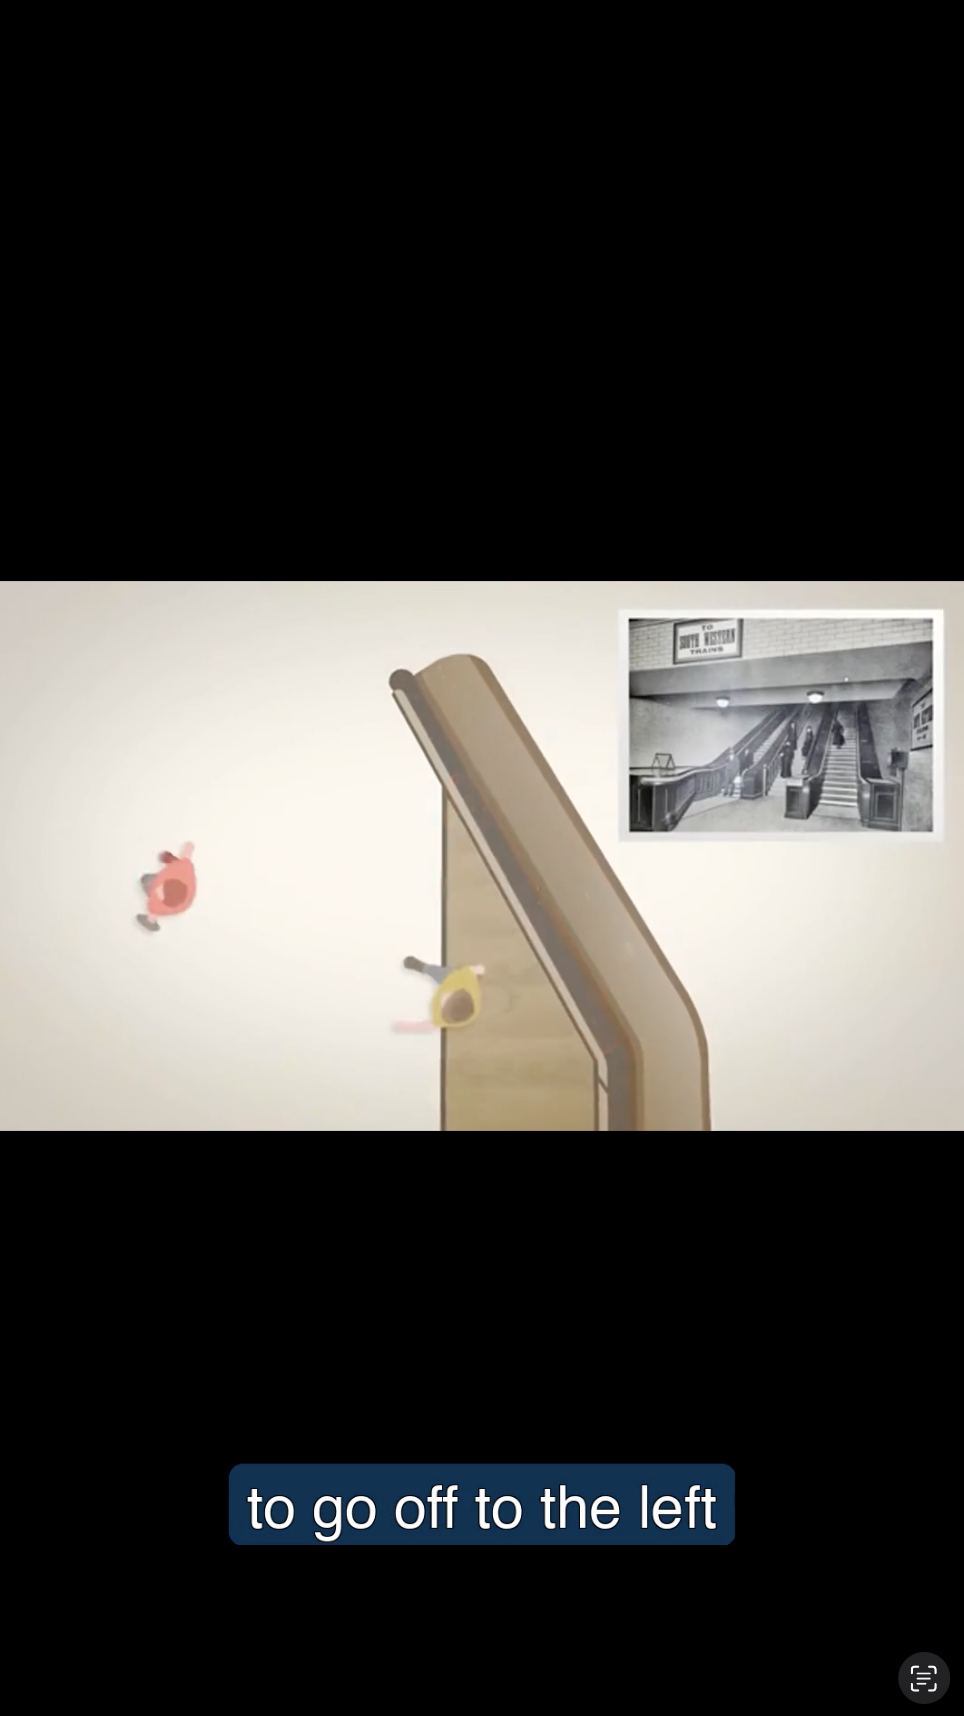|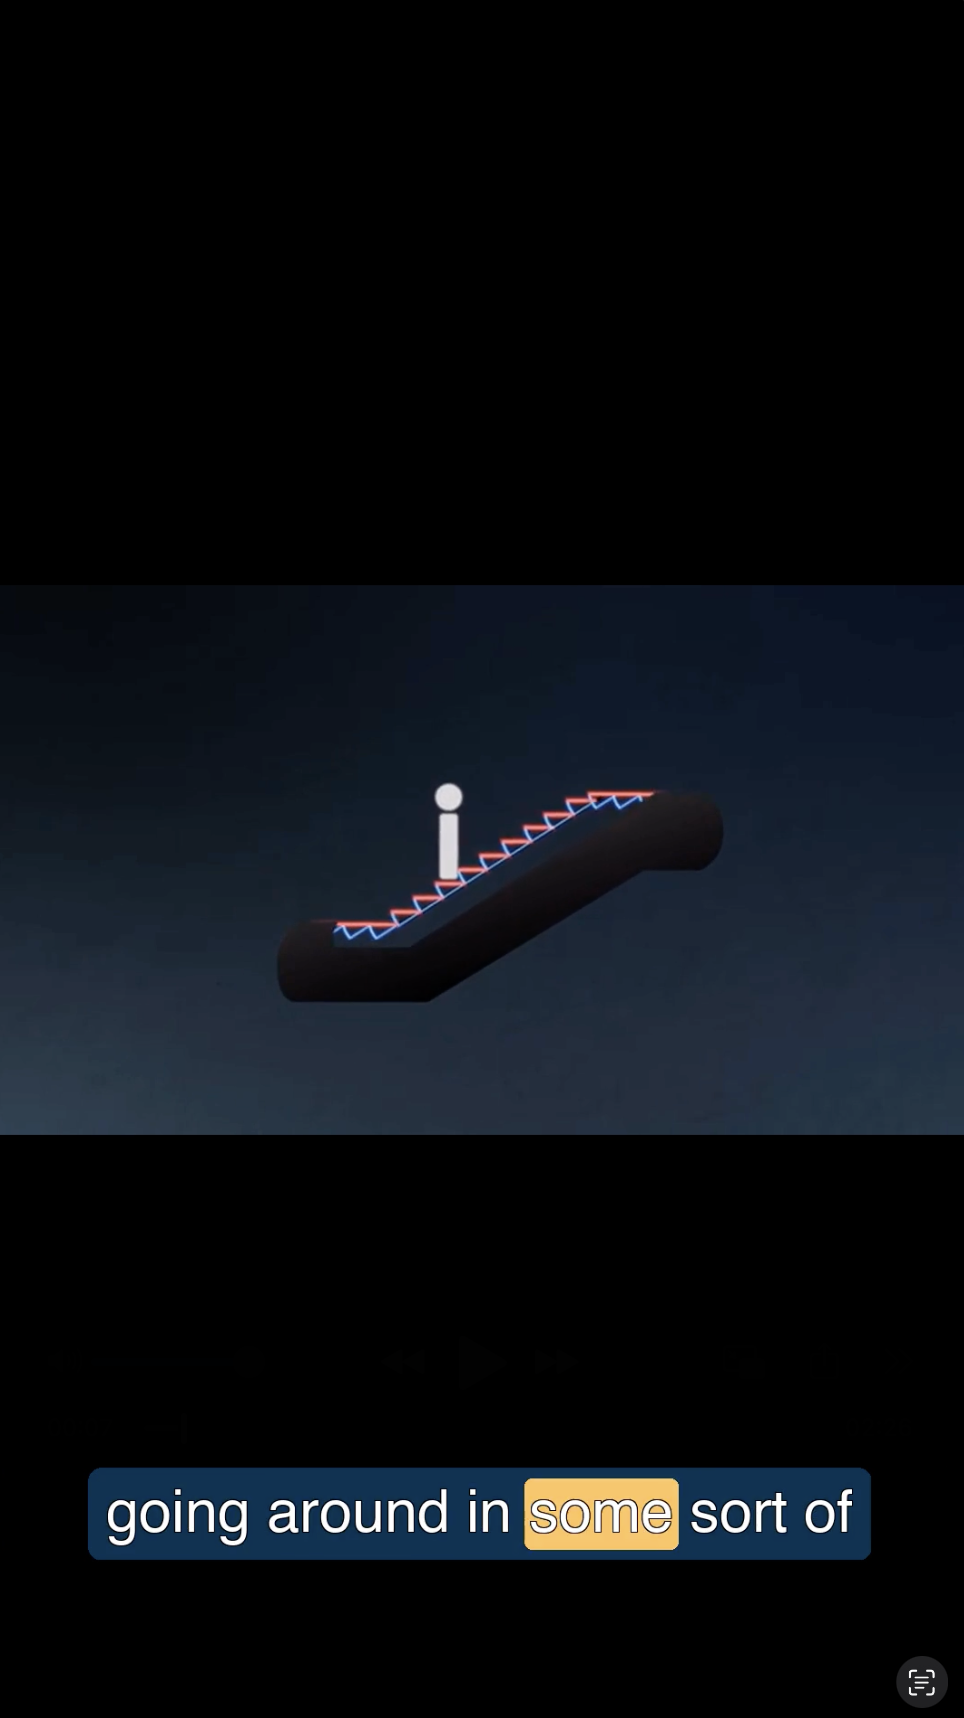|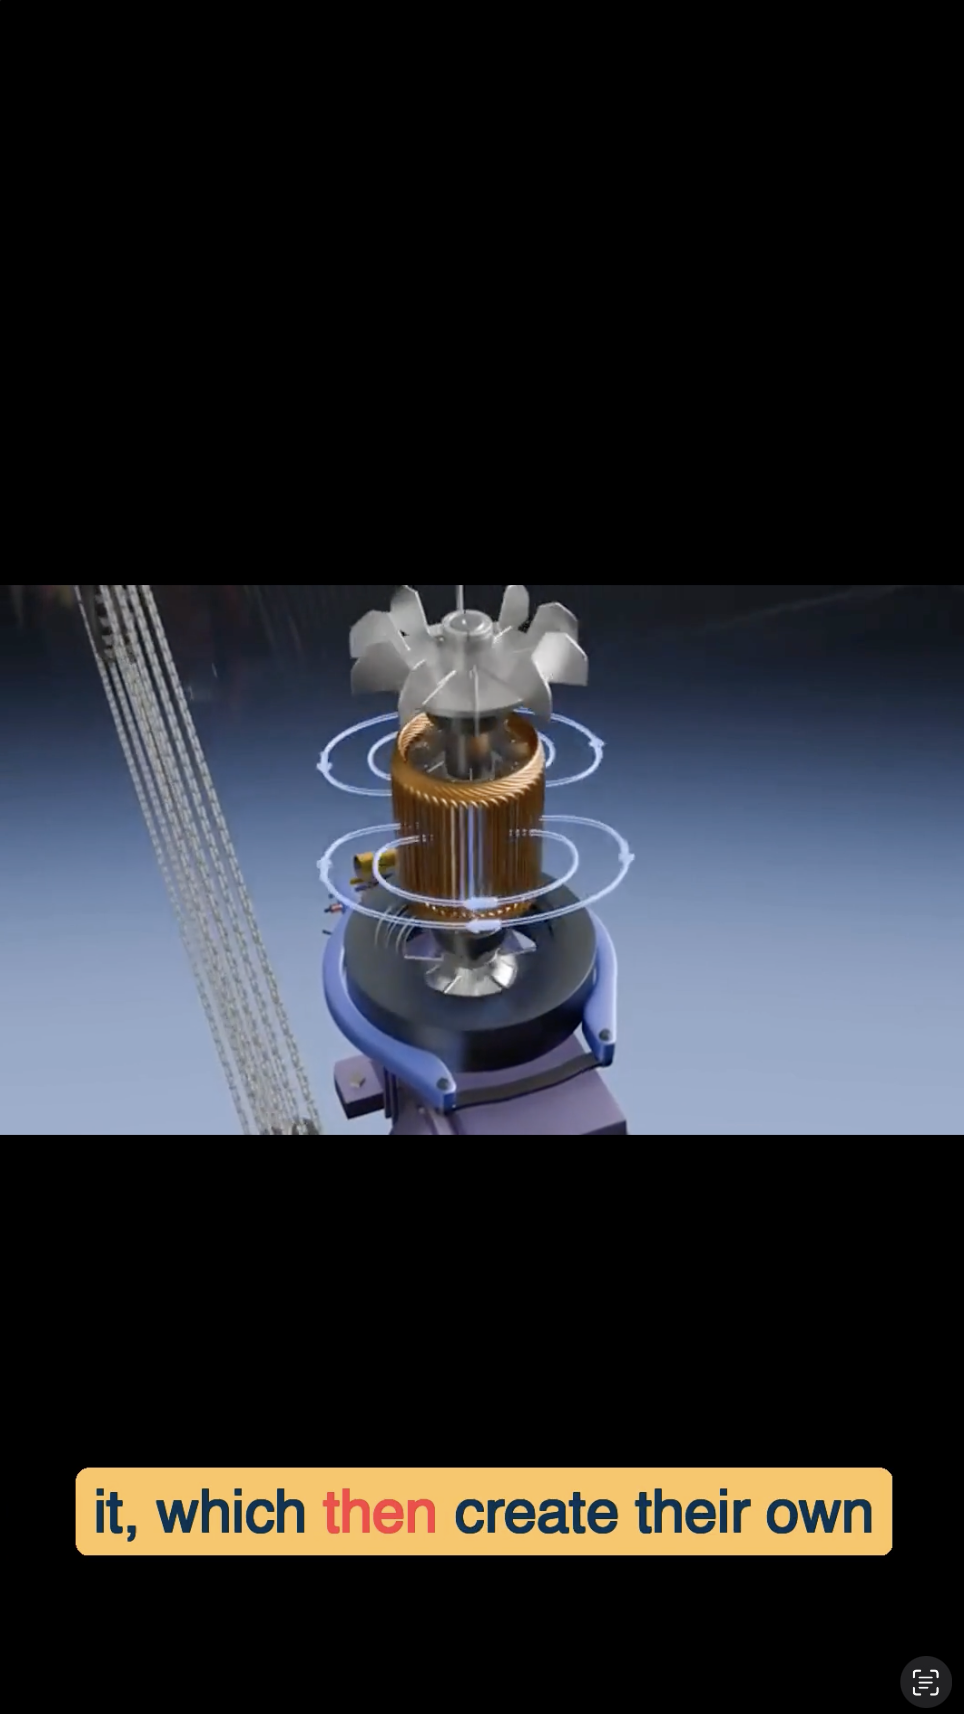|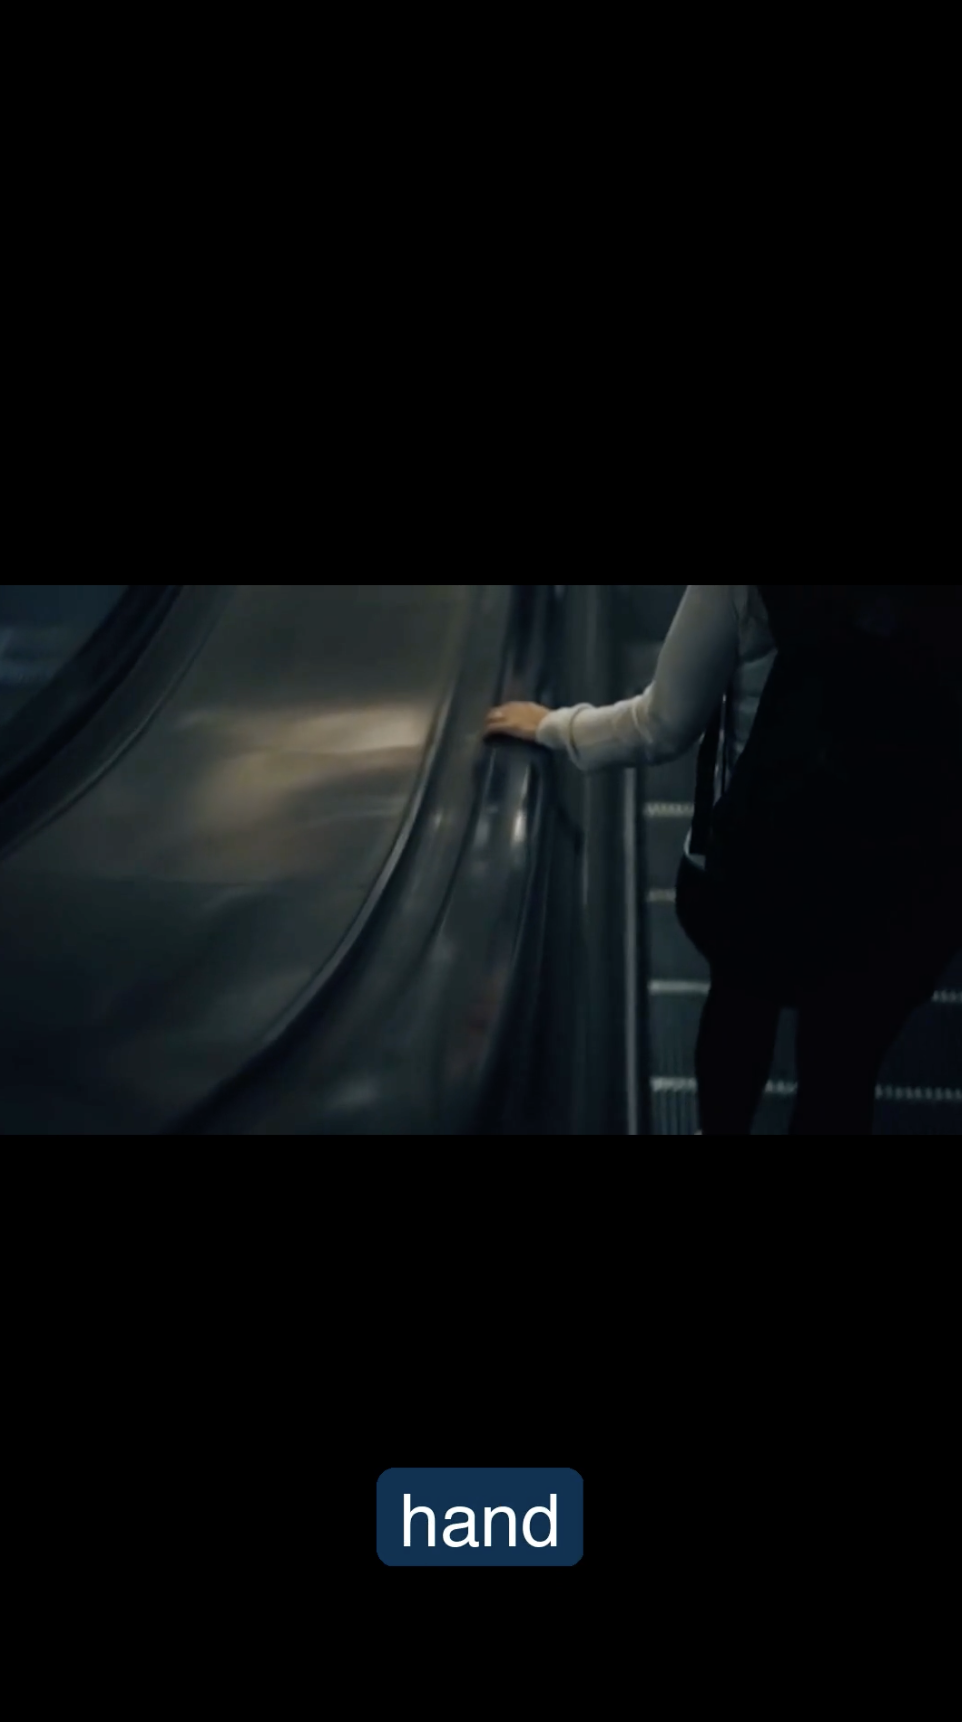|

In [22]:
# Step 11: MoviePy + PIL Advanced Caption Implementation

# Import required libraries
from moviepy import ImageClip, VideoFileClip, CompositeVideoClip
from PIL import Image, ImageDraw, ImageFont
import numpy as np

# Caption Style Presets
DARK_GREY = (0, 48, 73, 255)
YELLOW = (255, 189, 89, 255)
RED = (239, 35, 60, 255)
WHITE = (255, 255, 255, 255)

CAPTION_PRESETS = {
    # 'sentence_highlight': {
    #     'name': 'Sentence with Word Highlight',
    #     'description': 'Full sentence visible with current word highlighted in yellow',
    #     'font_size': 65,
    #     'bg_color': DARK_GREY,
    #     'text_color': WHITE,
    #     'highlight_color': YELLOW,
    #     'padding': 20,
    #     'border_radius': 15,
    #     'mode': 'sentence'
    # },
    # 'word_background': {
    #     'name': 'Highlighted Word Background',
    #     'description': 'Full sentence with highlighted background behind current word',
    #     'font_size': 65,
    #     'bg_color': DARK_GREY,
    #     'text_color': WHITE,
    #     'highlight_bg_color': YELLOW,
    #     'padding': 20,
    #     'border_radius': 15,
    #     'word_bg_radius': 8,
    #     'mode': 'word_background'
    # },
    'sentence_bg_highlight': {
        'name': 'Sentence Background + Word Text',
        'description': 'Highlighted sentence background with current word in different color',
        'font_size': 65,
        'bg_color': YELLOW,
        'text_color': DARK_GREY,
        'highlight_color': RED,
        'padding': 20,
        'border_radius': 15,
        'mode': 'sentence_bg'
    },
    'single_word': {
        'name': 'Single Word Display',
        'description': 'One word at a time with rounded background',
        'font_size': 80,
        'bg_color': YELLOW,
        'text_color': DARK_GREY,
        'padding': 25,
        'border_radius': 20,
        'mode': 'single_word'
    }
}

def draw_rounded_rectangle(draw, bbox, radius, fill):
    """Draw a rounded rectangle"""
    x1, y1, x2, y2 = bbox
    # Draw main rectangle
    draw.rectangle([x1, y1 + radius, x2, y2 - radius], fill=fill)
    draw.rectangle([x1 + radius, y1, x2 - radius, y2], fill=fill)
    
    # Draw corners
    draw.pieslice([x1, y1, x1 + radius * 2, y1 + radius * 2], 180, 270, fill=fill)
    draw.pieslice([x2 - radius * 2, y1, x2, y1 + radius * 2], 270, 360, fill=fill)
    draw.pieslice([x1, y2 - radius * 2, x1 + radius * 2, y2], 90, 180, fill=fill)
    draw.pieslice([x2 - radius * 2, y2 - radius * 2, x2, y2], 0, 90, fill=fill)

def create_sentence_image_with_highlight(sentence_words, highlight_idx, style, video_width=1080):
    """Create a sentence image with highlighted word using PIL"""
    
    font_size = style['font_size']
    bg_color = style['bg_color']
    text_color = style['text_color']
    padding = style['padding']
    border_radius = style['border_radius']
    mode = style['mode']
    
    # Load system font
    font = ImageFont.truetype("/System/Library/Fonts/Helvetica.ttc", font_size)
    
    # Create sentence text with words
    words_text = [word['word'] for word in sentence_words]
    
    if mode == 'single_word':
        # Single word mode
        current_word = words_text[highlight_idx]
        temp_img = Image.new('RGBA', (1000, 200), (0, 0, 0, 0))
        temp_draw = ImageDraw.Draw(temp_img)
        
        word_bbox = temp_draw.textbbox((0, 0), current_word, font=font)
        word_width = word_bbox[2] - word_bbox[0]
        word_height = word_bbox[3] - word_bbox[1]
        
        img_width = word_width + (padding * 2)
        img_height = word_height + (padding * 2)
        
        img = Image.new('RGBA', (img_width, img_height), (0, 0, 0, 0))
        draw = ImageDraw.Draw(img)
        
        # Draw rounded background
        draw_rounded_rectangle(draw, (0, 0, img_width, img_height), border_radius, bg_color)
        
        # Draw word
        text_x = (img_width - word_width) // 2
        text_y = (img_height - word_height) // 2
        draw.text((text_x, text_y), current_word, font=font, fill=text_color)
        
        return np.array(img)
    
    # Sentence modes
    temp_img = Image.new('RGBA', (2000, 200), (0, 0, 0, 0))
    temp_draw = ImageDraw.Draw(temp_img)
    
    # Measure individual words and their positions
    word_positions = []
    current_x = 0
    
    for i, word in enumerate(words_text):
        word_bbox = temp_draw.textbbox((current_x, 0), word, font=font)
        word_width = word_bbox[2] - word_bbox[0]
        word_height = word_bbox[3] - word_bbox[1]
        
        word_positions.append({
            'word': word,
            'x': current_x,
            'width': word_width,
            'height': word_height,
            'highlighted': (i == highlight_idx)
        })
        
        current_x += word_width
        
        if i < len(words_text) - 1:
            space_width = temp_draw.textbbox((0, 0), " ", font=font)[2]
            current_x += space_width
    
    # Calculate total dimensions
    total_text_width = current_x
    text_height = max(pos['height'] for pos in word_positions)
    
    img_width = min(total_text_width + (padding * 2), video_width - 40)
    img_height = text_height + (padding * 2)
    
    img = Image.new('RGBA', (img_width, img_height), (0, 0, 0, 0))
    draw = ImageDraw.Draw(img)
    
    # Draw main background
    draw_rounded_rectangle(draw, (0, 0, img_width, img_height), border_radius, bg_color)
    
    # Calculate starting position
    start_x = (img_width - total_text_width) // 2
    text_y = padding
    
    # Draw words based on mode
    current_x = start_x
    for word_info in word_positions:
        word = word_info['word']
        
        if mode == 'word_background' and word_info['highlighted']:
            # Draw highlighted background behind word with consistent Y positioning
            word_bg_padding = 5
            # Use consistent Y positioning for all words to ensure smooth transitions
            consistent_y_padding = 8  # Safe padding to cover all alphabet heights
            word_bg_x1 = current_x - word_bg_padding
            word_bg_y1 = text_y - consistent_y_padding  # Consistent Y top
            word_bg_x2 = current_x + word_info['width'] + word_bg_padding
            word_bg_y2 = text_y + text_height + consistent_y_padding  # Consistent Y bottom
            
            draw_rounded_rectangle(draw, 
                (word_bg_x1, word_bg_y1, word_bg_x2, word_bg_y2), 
                style['word_bg_radius'], 
                style['highlight_bg_color'])
        
        # Determine text color
        if mode == 'sentence_highlight':
            color = style['highlight_color'] if word_info['highlighted'] else text_color
            outline_color = (0, 0, 0, 255)  # Black outline
        elif mode == 'sentence_bg':
            color = style['highlight_color'] if word_info['highlighted'] else text_color
            outline_color = color  # Match outline with text color
        else:  # word_background
            color = text_color
            outline_color = (0, 0, 0, 255)  # Black outline
        
        # Draw text outline for better visibility
        for adj in range(-1, 2):
            for adj2 in range(-1, 2):
                if adj != 0 or adj2 != 0:
                    draw.text((current_x + adj, text_y + adj2), word, font=font, fill=outline_color)
        
        # Draw main text
        draw.text((current_x, text_y), word, font=font, fill=color)
        
        # Move to next word position
        current_x += word_info['width']
        if word_info != word_positions[-1]:
            space_width = draw.textbbox((0, 0), " ", font=font)[2]
            current_x += space_width
    
    return np.array(img)

def create_moviepy_advanced_captions(story_data, transcript_data, input_video_path, output_path, preset_name):
    """Create advanced captions using MoviePy + PIL with style presets"""
    
    style = CAPTION_PRESETS[preset_name]
    
    # Load video
    video = VideoFileClip(input_video_path)
    video_duration = video.duration
    
    # Collect all words with timestamps for this story
    all_caption_words = []
    story_start_time = story_data['clips'][0]['start_time']
    
    for clip in story_data['clips']:
        start_idx = clip['start_index']
        end_idx = clip['end_index']
        
        # Get words for this clip
        clip_words = transcript_data['words'][start_idx:end_idx+1]
        
        for word_data in clip_words:
            # Calculate relative timestamp within the story
            word_time_in_story = word_data['start'] - story_start_time
            if word_time_in_story < 0:
                word_time_in_story = 0
            
            # Clean word
            clean_word = word_data['word'].strip()
            if clean_word:
                all_caption_words.append({
                    'word': clean_word,
                    'start_time': word_time_in_story,
                    'duration': min(word_data['end'] - word_data['start'], 1.5)
                })
    
    if not all_caption_words:
        return input_video_path
    caption_clips = []
    
    if style['mode'] == 'single_word':
        # Single word mode - show one word at a time
        for word_idx, word_info in enumerate(all_caption_words):
            word_img_array = create_sentence_image_with_highlight(
                [word_info],  # Single word as sentence
                0,  # Highlight index is always 0 for single word
                style,
                video_width=int(video.w)
            )
            
            word_clip = ImageClip(word_img_array, duration=word_info['duration'])
            word_clip = word_clip.with_start(word_info['start_time'])
            word_clip = word_clip.with_position(('center', 0.85), relative=True)
            word_clip = word_clip.with_position(('center', 0.85), relative=True)
            caption_clips.append(word_clip)
            
            if word_info['start_time'] + word_info['duration'] > video_duration:
                break
    
    else:
        # Sentence modes - group words into sentences
        sentences = []
        current_sentence = []
        
        for word_info in all_caption_words:
            current_sentence.append(word_info)
            
            if len(current_sentence) >= 3 or word_info == all_caption_words[-1]:
                if current_sentence:
                    sentences.append(current_sentence.copy())
                    current_sentence = []
        
        for sentence_idx, sentence_words in enumerate(sentences):
            for word_idx, word_info in enumerate(sentence_words):
                sentence_img_array = create_sentence_image_with_highlight(
                    sentence_words,
                    word_idx, 
                    style,
                    video_width=int(video.w)
                )
                
                word_clip = ImageClip(sentence_img_array, duration=word_info['duration'])
                word_clip = word_clip.with_start(word_info['start_time'])
                word_clip = word_clip.with_position(('center', 0.85), relative=True)
                word_clip = word_clip.with_position(('center', 0.85), relative=True)
                caption_clips.append(word_clip)
                
                if word_info['start_time'] + word_info['duration'] > video_duration:
                    break
    
    # Composite video with all caption clips
    final_video = CompositeVideoClip([video] + caption_clips)
    
    # Safe filename
    safe_title = re.sub(r'[^\w\-_]', '_', story_data['story_title'])
    output_file = os.path.join(output_path, f"{preset_name}_story_{story_data['story_index']}_{safe_title}.mp4")
    
    # Write final video
    final_video.write_videofile(
        output_file,
        codec='libx264',
        audio_codec='aac'
    )
    
    # Close clips to free memory
    final_video.close()
    video.close()

    
    video.close()

    return output_file    

In [14]:
def create_captioned_story(story, preset_style):
    # Setup paths
    moviepy_folder = os.path.join(output_folder, "moviepy_captions")
    os.makedirs(moviepy_folder, exist_ok=True)
    
    # Find the original clip for this story
    safe_title = re.sub(r'[^\w\-_]', '_', story['story_title'])
    story_index = next((i+1 for i, s in enumerate(processed_stories) if s['story_title'] == story['story_title']), 1)
    original_clip_path = os.path.join(output_folder, f"story_{story_index}_{safe_title}.mp4")
    
    # Validate inputs
    if preset_style not in CAPTION_PRESETS:
        print(f"❌ Invalid preset style '{preset_style}'. Available styles:")
        for name, info in CAPTION_PRESETS.items():
            print(f"   - {name}: {info['description']}")
        return None
    
    if not os.path.exists(original_clip_path):
        print(f"❌ Original clip not found: {original_clip_path}")
        print("💡 Make sure to run the video clipping steps first")
        return None
    
    # Prepare story data
    story_with_index = story.copy()
    story_with_index['story_index'] = story_index
    
    # Create caption
    preset_info = CAPTION_PRESETS[preset_style]
    print(f"🎨 Creating: {preset_info['name']}")
    print(f"   📝 {preset_info['description']}")
    print(f"   📹 Input: {os.path.basename(original_clip_path)}")
    
    result = create_moviepy_advanced_captions(
        story_with_index,
        transcript_data,
        original_clip_path,
        moviepy_folder,
        preset_style
    )
    
    if result:
        file_size = os.path.getsize(result) / (1024 * 1024)
        print(f"   ✅ Created: {os.path.basename(result)} ({file_size:.1f} MB)")
        return result
    else:
        print(f"   ❌ Failed to create {preset_style} style")
        return None

print("📋 Available caption styles:")
for name, info in CAPTION_PRESETS.items():
    print(f"  {name}: {info['description']}")

print(f"\n📚 Available stories:")
for i, story in enumerate(processed_stories):
    print(f"  {i}: {story['story_title']}")

📋 Available caption styles:
  sentence_bg_highlight: Highlighted sentence background with current word in different color
  single_word: One word at a time with rounded background

📚 Available stories:
  0: How does this Wordle bot consistently get birdies?
  1: Why did a genius name this 'Entropy'?
  2: What's the BEST Wordle opener? An AI finds a surprising answer!


#### ⚠️ Warning: Resource heavy processing ahead
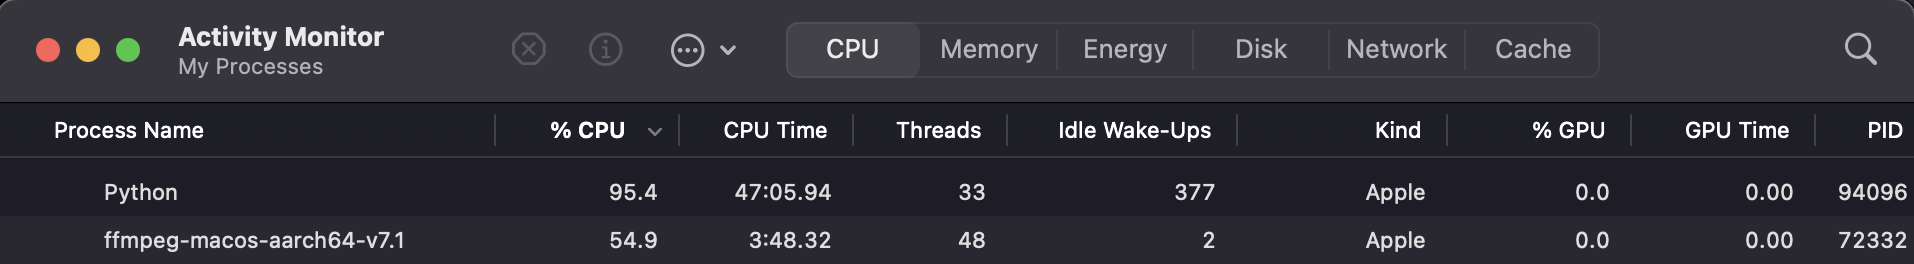

In [15]:
# fire concurrent processing for all stories (idempotent)
from concurrent.futures import ThreadPoolExecutor


def run_story(i_story):
    i, story = i_story
    presets = list(CAPTION_PRESETS.keys())
    preset = presets[i % len(presets)]

    # Compute expected output path for this preset/story
    moviepy_folder = os.path.join(output_folder, "moviepy_captions")
    safe_title = re.sub(r'[^\w\-_]', '_', story['story_title'])
    story_index = next((j + 1 for j, s in enumerate(processed_stories) if s['story_title'] == story['story_title']), i + 1)
    expected_out = os.path.join(moviepy_folder, f"{preset}_story_{story_index}_{safe_title}.mp4")

    if os.path.exists(expected_out) and os.path.getsize(expected_out) > 0:
        print(f"⏭️  Skipping (already exists): {expected_out}")
        return expected_out

    try:
        return create_captioned_story(story, preset)
    except Exception as e:
        print(f"❌ Failed story {story_index} ({preset}): {e}")
        return None


if not processed_stories:
    print("No processed stories found; nothing to caption.")
else:
    with ThreadPoolExecutor() as executor:
        list(executor.map(run_story, enumerate(processed_stories)))


⏭️  Skipping (already exists): out/v68zYyaEmEA/moviepy_captions/single_word_story_2_Why_did_a_genius_name_this__Entropy__.mp4⏭️  Skipping (already exists): out/v68zYyaEmEA/moviepy_captions/sentence_bg_highlight_story_1_How_does_this_Wordle_bot_consistently_get_birdies_.mp4

⏭️  Skipping (already exists): out/v68zYyaEmEA/moviepy_captions/sentence_bg_highlight_story_3_What_s_the_BEST_Wordle_opener__An_AI_finds_a_surprising_answer_.mp4


In [ ]:
# # sync call to see streaming progress
# create_captioned_story(processed_stories[2], 'sentence_bg_highlight')